# Cuaderno 2: Matriz inversa

En este cuaderno trabajamos dos temas relacionados:

1. **Matriz inversa**: existencia, significado y métodos básicos para calcularla.
2. **Matrices y sistemas**: cómo la invertibilidad de una matriz se conecta con las soluciones de un sistema $Ax=b$.

Todo el análisis se hace con **operaciones de fila** (Gauss-Jordan) y el **rango**, sin usar determinantes.
Usamos `sympy` para hacer los cálculos simbólicos (fracciones exactas, no decimales).

In [1]:
from sympy import Matrix, Rational, symbols, eye, init_printing
init_printing()  # para que las matrices se vean bonitas

## 1. ¿Qué es la matriz inversa?

Dada una matriz **cuadrada** $A$ de tamaño $n\times n$, decimos que $A$ es **invertible** (o **no singular**) si existe una matriz $A^{-1}$ tal que

$$A A^{-1} = A^{-1}A = I_n$$

donde $I_n$ es la matriz identidad de tamaño $n$.

Puntos clave:

- Solo las matrices **cuadradas** pueden tener inversa (una matriz de $m\times n$ con $m\neq n$ nunca es invertible).
- No toda matriz cuadrada tiene inversa: si no la tiene, se llama **singular**.
- Si la inversa existe, es **única**.

### Significado de la inversa

Si pensamos en $A$ como una transformación lineal que envía $x \mapsto Ax$, entonces $A^{-1}$ es la transformación que **deshace** ese efecto: $A^{-1}(Ax) = x$.

Esto es útil para resolver sistemas de ecuaciones: si $Ax = b$ y $A$ es invertible, entonces

$$x = A^{-1}b$$

es la única solución del sistema.

## 2. ¿Cómo saber si existe, sin calcular la inversa?

En vez de usar el determinante, usamos algo más directo: llevar $A$ a su **forma escalonada reducida** (RREF, reduced row echelon form) mediante operaciones de fila.

- Si la forma escalonada reducida de $A$ es la identidad $I_n$ (es decir, hay un pivote en cada fila y en cada columna), entonces $A$ es invertible.
- Si al reducir aparece alguna **fila de ceros**, entonces $A$ no tiene $n$ pivotes: es **singular** y no tiene inversa.

Esto equivale a decir que el **rango** de $A$ (el número de pivotes, calculado con `rank()`) debe ser igual a $n$.

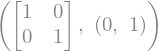

In [2]:
A = Matrix([[2, 1], [1, 1]])
A.rref()  # (forma escalonada reducida, columnas pivote)

In [3]:
A.rank()  # rango = numero de pivotes; si es igual al tamano de A, es invertible

## 3. Método básico: eliminación de Gauss-Jordan sobre $[A \mid I]$

Para calcular la inversa (no solo saber si existe), el método más usado en la práctica es:

1. Formar la matriz aumentada $[A \mid I]$.
2. Aplicar operaciones de fila (las mismas que en reducción de sistemas) hasta llevar el bloque izquierdo a la identidad.
3. El bloque derecho queda convertido en $A^{-1}$: $[A \mid I] \to [I \mid A^{-1}]$.

Si en el proceso una fila del bloque izquierdo se hace cero por completo, la matriz **no es invertible** y el proceso se detiene ahí.

Veamos un ejemplo paso a paso con

$$A = \begin{bmatrix} 2 & 1 & 1 \\ 1 & 3 & 2 \\ 1 & 0 & 0 \end{bmatrix}$$

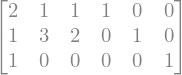

In [4]:
A = Matrix([
    [2, 1, 1],
    [1, 3, 2],
    [1, 0, 0]
])
M = A.row_join(eye(3))  # matriz aumentada [A | I]
M

### Paso 1: pivote de la fila 1

$R_1 \to \frac{1}{2}R_1$

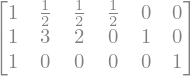

In [5]:
M[0, :] = M[0, :] / 2
M

### Paso 2: eliminar la columna 1 debajo del pivote

$R_2 \to R_2 - R_1$, $R_3 \to R_3 - R_1$

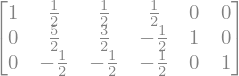

In [6]:
M[1, :] = M[1, :] - M[0, :]
M[2, :] = M[2, :] - M[0, :]
M

### Paso 3: pivote de la fila 2

$R_2 \to \frac{1}{\,5/2\,}R_2 = \frac{2}{5}R_2$

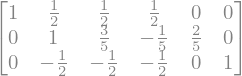

In [7]:
M[1, :] = M[1, :] * Rational(2, 5)
M

### Paso 4: eliminar la columna 2 arriba y abajo del pivote

$R_1 \to R_1 - \frac{1}{2}R_2$, $R_3 \to R_3 + \frac{1}{2}R_2$

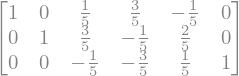

In [8]:
M[0, :] = M[0, :] - Rational(1, 2) * M[1, :]
M[2, :] = M[2, :] + Rational(1, 2) * M[1, :]
M

### Paso 5: pivote de la fila 3

$R_3 \to \frac{1}{-1/5}R_3 = -5R_3$

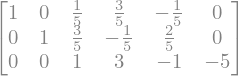

In [9]:
M[2, :] = M[2, :] * (-5)
M

### Paso 6: eliminar la columna 3 arriba del pivote

Con $R_1$ y $R_2$ para dejar el bloque izquierdo como identidad.

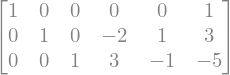

In [10]:
M[0, :] = M[0, :] - M[2, :] * M[0, 2]
M[1, :] = M[1, :] - M[2, :] * M[1, 2]
M

El bloque izquierdo ya es $I_3$ (todas las filas tienen pivote), así que $A$ es invertible y el bloque derecho es $A^{-1}$. Comprobemos con el método directo de `sympy`:

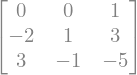

In [11]:
A.inv()  # debe coincidir con las 3 ultimas columnas de M

## 4. Matrices y sistemas: condiciones de invertibilidad

Para una matriz cuadrada $A$ de $n\times n$, las siguientes afirmaciones son **equivalentes** (si una es cierta, todas lo son; si una falla, todas fallan). Esto se conoce como el **Teorema de la Matriz Invertible** (versión sin determinantes):

1. $A$ es invertible.
2. La forma escalonada reducida de $A$ es la identidad $I_n$.
3. $A$ tiene $n$ pivotes (rango completo: $\mathrm{rango}(A) = n$).
4. El sistema $Ax = 0$ solo tiene la solución trivial $x = 0$.
5. El sistema $Ax = b$ tiene **exactamente una** solución para **cada** vector $b$.
6. Las columnas de $A$ son linealmente independientes.
7. Las filas de $A$ son linealmente independientes.

Si el rango de $A$ es menor que $n$, la matriz es **singular**: no tiene inversa, y el sistema $Ax=b$ tiene **infinitas soluciones** (si $b$ es compatible con las filas) o **ninguna solución** (si no lo es).

### Ejemplo: matriz invertible

In [12]:
A = Matrix([[2, 1, 1], [1, 3, 2], [1, 0, 0]])
A.rank()  # si es igual a 3 (numero de filas/columnas), es invertible

Como el rango es $3$ (rango completo), $A$ es invertible y el sistema $Ax=b$ tiene solución única para cualquier $b$.

In [13]:
b = Matrix([4, 6, 1])
x = A.inv() * b
x

In [14]:
# Comprobacion: A*x debe dar b
A * x

### Ejemplo: matriz singular

$$B = \begin{bmatrix} 1 & 2 & 3 \\ 2 & 4 & 6 \\ 1 & 1 & 1 \end{bmatrix}$$

Aquí la fila 2 es múltiplo de la fila 1 ($R_2 = 2R_1$), así que al reducir esperamos que salga una fila de ceros.

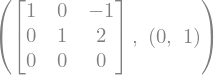

In [15]:
B = Matrix([[1, 2, 3], [2, 4, 6], [1, 1, 1]])
B.rref()

In [16]:
B.rank()  # menor que 3: no tiene rango completo

El rango es menor que $3$ (aparece una fila de ceros al reducir): $B$ **no** es invertible. Si intentamos calcular `B.inv()` obtenemos un error.

In [17]:
try:
    B.inv()
except Exception as e:
    print(type(e).__name__, "-", e)

NonInvertibleMatrixError - Matrix det == 0; not invertible.


Veamos qué pasa con el sistema $Bx = b$ para dos elecciones de $b$: una **compatible** (infinitas soluciones) y otra **incompatible** (sin solución).

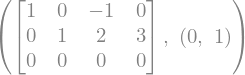

In [18]:
# Caso compatible: b es combinacion de las filas de B de forma consistente
b1 = Matrix([6, 12, 3])  # b1 = 3 * (columna correspondiente a la solucion x=[1,1,1])
sistema1 = B.row_join(b1)
sistema1.rref()  # forma escalonada reducida: si aparece una fila libre, hay infinitas soluciones

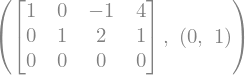

In [19]:
# Caso incompatible
b2 = Matrix([6, 12, 5])
sistema2 = B.row_join(b2)
sistema2.rref()  # si aparece una fila [0 0 0 | c] con c != 0, el sistema no tiene solucion

## Resumen

- $A$ invertible $\iff$ rango completo (n pivotes) $\iff$ RREF de $A$ es la identidad $\iff$ columnas/filas independientes $\iff$ $Ax=b$ tiene solución única para todo $b$.
- Para calcular $A^{-1}$, el método básico es Gauss-Jordan sobre $[A\mid I]$: se reduce el bloque izquierdo a la identidad y el bloque derecho queda como $A^{-1}$.
- Si al reducir aparece una fila de ceros en el bloque izquierdo, la matriz es singular: no existe $A^{-1}$, y el sistema asociado tiene infinitas soluciones o ninguna, nunca exactamente una.

## Ejercicios propuestos

### Ejercicio 1

Calcula, a mano y luego con `sympy`, la inversa de

$$A = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix}$$

usando Gauss-Jordan sobre $[A\mid I]$, y verifica que $AA^{-1} = I$.

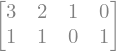

In [5]:
# Ejercicio 1
A = Matrix([[3, 2], [1, 1]])
B = A.row_join(eye(2))
B


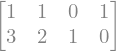

In [7]:
B[1,:], B[0,:] = B[0,:], B[1,:]
B 

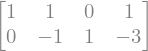

In [8]:
B[1,:] = B[1,:] - 3*B[0,:]
B

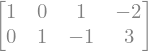

In [9]:
B[1,:] = -1*B[1,:]
B[0,:] = B[0,:] - B[1,:]
B

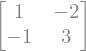

In [10]:
A.inv()

### Ejercicio 2

Usa el método de Gauss-Jordan (paso a paso, como en la sección 3) para hallar la inversa de

$$A = \begin{bmatrix} 1 & 2 & 3 \\ 0 & 1 & 4 \\ 5 & 6 & 0 \end{bmatrix}$$

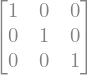

In [12]:
# Ejercicio 2: matriz aumentada [A | I]
A = Matrix([[1, 2, 3], [0, 1, 4], [5, 6, 0]])
B = Matrix([[-24, 18, 5], [20, -15, -4], [-5,4,1]])
A*B

### Ejercicio 3

Sin calcular la inversa completa, determina si la siguiente matriz es invertible usando su **rango** (con `rank()` o `rref()`):

$$C = \begin{bmatrix} 1 & 2 & -1 \\ 2 & 4 & -2 \\ 0 & 1 & 3 \end{bmatrix}$$

Explica, usando el Teorema de la Matriz Invertible, qué le pasaría al sistema $Cx=b$ para distintos $b$.

In [22]:
# Ejercicio 3
C = Matrix([[1, 2, -1], [2, 4, -2], [0, 1, 3]])


### Ejercicio 4: producción, consumo interno y modelo de Leontief

Una economía tiene dos sectores, Agricultura (1) y Manufactura (2), con matriz de coeficientes tecnológicos

$$A = \begin{bmatrix} 0.2 & 0.3 \\ 0.4 & 0.1 \end{bmatrix}$$

donde $a_{ij}$ es cuánto del sector $i$ se necesita como insumo para producir una unidad del sector $j$.

**a)** Si se producen $x_1=100$ de agricultura y $x_2=200$ de manufactura ¿cuánto se consume en el proceso de producción) y cuánto queda de excedente para demanda final?

**b)** Ahora al revés: si se quiere satisfacer una demanda final $d=\begin{bmatrix}100\\80\end{bmatrix}$, ¿cuánto se debe producir en total? Es decir, resuelve $(I-A)x=d$ verificando primero (con el rango) que $I-A$ es invertible.

**c)** Comprueba el resultado de b) calculando $(I-A)x$ y viendo que da $d$.

In [23]:
# Ejercicio 4
A = Matrix([[Rational(2, 10), Rational(3, 10)], [Rational(4, 10), Rational(1, 10)]])
I = eye(2)

# a) x dado, calcular consumo interno A*x y excedente x - A*x
x = Matrix([100, 200])

# b) d dado, verificar rango de (I-A) y resolver x = (I-A)^{-1} d
d = Matrix([100, 80])

# c) comprobacion: (I-A)*x debe dar d


## Preguntas conceptuales: productos de matrices especiales

Para cada pregunta, responde primero razonando (sin calcular), y luego comprueba tu respuesta construyendo un ejemplo numerico con `sympy`. Si tu conjetura falla, ajusta el enunciado con la condicion adicional que la hace verdadera.


## Preguntas conceptuales: productos de matrices especiales

Para cada pregunta, responde primero razonando (sin calcular), y luego comprueba tu respuesta construyendo un ejemplo numérico con `sympy`. Si tu conjetura falla, ajusta el enunciado con la condición adicional que la hace verdadera.


### Pregunta 1: producto de matrices simétricas

Si $A$ y $B$ son simétricas ($A^T=A$, $B^T=B$), ¿es $AB$ necesariamente simétrica?

- Justifica usando la propiedad $(AB)^T = B^T A^T$.
- ¿Bajo qué condición adicional sobre $A$ y $B$ sí se garantiza que $AB$ es simétrica?


In [ ]:
# Pregunta 1: comprueba con dos matrices simetricas A y B
A = Matrix([[2, 1], [1, 3]])
B = Matrix([[4, 5], [5, 6]])

# Verifica que A y B son simetricas, calcula A*B y compara con (A*B).T


### Pregunta 2: producto de matrices triangulares superiores

Si $A$ y $B$ son triangulares superiores, ¿es $AB$ triangular superior? ¿Y $A+B$?

- Piensa en qué pasa con la entrada $(i,j)$ del producto cuando $i>j$.
- ¿La diagonal de $AB$ tiene alguna relación sencilla con las diagonales de $A$ y $B$?


In [ ]:
# Pregunta 2: comprueba con dos matrices triangulares superiores A y B
A = Matrix([[1, 2, 3], [0, 4, 5], [0, 0, 6]])
B = Matrix([[7, 0, 1], [0, 8, 2], [0, 0, 9]])

# Calcula A*B y A+B, y observa su estructura. Compara la diagonal de A*B con las de A y B


### Pregunta 3: producto de matrices diagonales

Si $A$ y $B$ son diagonales, ¿es $AB$ diagonal? ¿Se cumple $AB=BA$ en este caso? Justifica por qué esto no es cierto para matrices cualesquiera.


In [ ]:
# Pregunta 3: comprueba con dos matrices diagonales A y B
A = diag(2, 5, -1)
B = diag(3, 0, 4)

# Calcula A*B y B*A y compara


### Pregunta 4 (síntesis): invertibilidad y estructura

Si $A$ es triangular superior e invertible, ¿$A^{-1}$ es también triangular superior? Si $A$ y $B$ son ambas triangulares superiores e invertibles, ¿qué puedes decir de $(AB)^{-1}$? Comprueba tus respuestas con un ejemplo.


In [ ]:
# Pregunta 4: comprueba con una matriz triangular superior invertible
A = Matrix([[2, 1, 0], [0, 3, 1], [0, 0, 4]])

# Calcula A**-1 y observa su estructura
